# Chapter 16. 고등학생 데이터 분석 실습: 게임 데이터로 배우는 문제 정의와 분석 흐름

이 노트북은 게임 데이터를 중심으로 데이터 분석 프로젝트를 이해하고 실습하는 자료입니다.

분석은 단순히 코드를 입력하는 것이 아니라 다음 순서를 따라가는 과정입니다.

1. 질문 정의
2. 데이터 수집
3. 전처리
4. 탐색적 분석(EDA)
5. 해석과 보고

이 흐름은 실제 데이터 분석 프로젝트에서 가장 기본적이고 중요한 구조입니다.

이번 장에서는 "게임 이용자 데이터"를 예시로 사용합니다. 예를 들어 게임의 플레이 시간, 레벨, 돈 지출, 로그인 횟수, 승패 기록 같은 정보를 분석해 어떤 요소가 게임의 재미와 유지에 영향을 주는지 살펴봅니다.

## 1. 데이터 분석이란?

데이터 분석은 단순히 데이터를 보는 것이 아니라 질문을 정하고, 그 질문에 답하기 위해 데이터를 수집하고 정리하며, 결과를 해석하는 과정입니다.

고등학생 수준에서 가장 중요한 점은 다음입니다.

- 무엇을 알고 싶은지 정한다.
- 어떤 데이터를 수집할지 정한다.
- 데이터를 깨끗하게 다듬는다.
- 그래프와 통계를 통해 의미를 찾는다.
- 결론을 설명한다.

이 과정을 데이터 분석 프로젝트의 기본 흐름이라고 합니다.

In [1]:
# 분석 흐름을 한눈에 보여주는 간단한 예시
steps = [
    "질문 정의",
    "데이터 수집",
    "전처리",
    "탐색적 분석(EDA)",
    "해석과 보고",
]

for i, step in enumerate(steps, start=1):
    print(f"{i}. {step}")

1. 질문 정의
2. 데이터 수집
3. 전처리
4. 탐색적 분석(EDA)
5. 해석과 보고


## 2. 질문 정의: 무엇을 알아보고 싶은가?

분석을 시작할 때는 먼저 질문을 정해야 합니다. 데이터가 많아 보여도 질문이 없으면 분석의 목적이 흐려집니다.

예를 들어 게임 데이터에서 다음과 같은 질문을 만들 수 있습니다.

- 고레벨 유저는 낮은 레벨 유저보다 더 오래 플레이하나?
- 게임에서 가장 많이 지출한 유저는 어떤 특성을 보이나?
- 플레이 시간과 승률 사이에 어떤 관계가 있나?
- 특정 시즌에 로그인 시간이 늘어나는지 확인할 수 있나?

이처럼 분석의 목적을 정하면 어떤 데이터를 수집해야 하는지 자연스럽게 정해집니다.

In [2]:
# 질문 예시를 딕셔너리로 정리
questions = {
    "Q1": "플레이 시간이 길수록 승률이 높을까?",
    "Q2": "게임 머니를 많이 지출한 유저는 더 높은 레벨에 도달할까?",
    "Q3": "로그인 빈도가 높은 유저가 더 오래 게임을 즐길까?",
    "Q4": "특정 게임 모드에서 승률이 다른가?",
}

for key, value in questions.items():
    print(f"{key}: {value}")

Q1: 플레이 시간이 길수록 승률이 높을까?
Q2: 게임 머니를 많이 지출한 유저는 더 높은 레벨에 도달할까?
Q3: 로그인 빈도가 높은 유저가 더 오래 게임을 즐길까?
Q4: 특정 게임 모드에서 승률이 다른가?


## 3. 데이터 수집: 어떤 데이터를 모을까?

분석을 위해서는 필요한 데이터를 먼저 모아야 합니다. 게임 분석에서는 보통 다음 같은 데이터를 수집합니다.

- 사용자 ID
- 플레이 시간
- 레벨
- 승패 결과
- 로그인 횟수
- 지출 금액
- 게임 모드
- 난이도

예시 데이터는 CSV 파일 형식으로 만들 수 있습니다. 아래는 간단한 게임 사용자 데이터 예시입니다.

In [3]:
import pandas as pd

# 게임 사용자 예시 데이터 생성
players = pd.DataFrame(
    {
        "user_id": ["U001", "U002", "U003", "U004", "U005"],
        "level": [5, 8, 12, 14, 20],
        "play_time_hours": [10, 18, 25, 32, 45],
        "win_rate": [0.45, 0.52, 0.61, 0.68, 0.74],
        "login_count": [8, 14, 16, 20, 27],
        "spend_amount": [0, 12000, 28000, 36000, 52000],
        "favorite_mode": ["Competitive", "Cooperative", "Competitive", "Cooperative", "Competitive"],
    }
)

print(players)

  user_id  level  play_time_hours  win_rate  login_count  spend_amount  \
0    U001      5               10      0.45            8             0   
1    U002      8               18      0.52           14         12000   
2    U003     12               25      0.61           16         28000   
3    U004     14               32      0.68           20         36000   
4    U005     20               45      0.74           27         52000   

  favorite_mode  
0            경쟁  
1            협동  
2            경쟁  
3            협동  
4            경쟁  


## 4. 데이터 수집 실습: CSV 파일로 저장하기

직접 만든 데이터는 파일로 저장해 두면 나중에 다시 불러와서 분석할 수 있습니다.

아래 코드는 게임 데이터를 CSV 파일로 저장하는 예시입니다.

In [4]:
from pathlib import Path

output_path = Path("game_players.csv")
players.to_csv(output_path, index=False)
print(f"저장 완료: {output_path.resolve()}")
print(output_path.read_text(encoding="utf-8")[:200])

저장 완료: C:\Users\juyoung\OneDrive\바탕 화면\python\python-edu-coin-trading\src\game_players.csv
user_id,level,play_time_hours,win_rate,login_count,spend_amount,favorite_mode
U001,5,10,0.45,8,0,경쟁
U002,8,18,0.52,14,12000,협동
U003,12,25,0.61,16,28000,경쟁
U004,14,32,0.68,20,36000,협동
U005,20,45,0.74,2


## 5. 전처리: 데이터를 분석하기 좋은 형태로 바꾸기

데이터를 모았다고 해서 바로 분석할 수 있는 것은 아닙니다. 데이터는 종종 비어 있거나 잘못된 값, 중복 값, 문자형 숫자 등이 섞여 있습니다.

전처리의 핵심은 다음입니다.

- 결측값 처리
- 이상치 확인
- 데이터형 변환
- 필요 없는 열 제거
- 새로운 의미 있는 변수 만들기

게임 데이터에서는 예를 들어 `spend_amount`가 문자열로 저장되거나, 일부 유저가 게임을 한 적이 없어서 `play_time_hours` 값이 비어 있을 수 있습니다.

In [5]:
# 전처리 예시: 결측값 및 이상치 처리
sample_players = pd.DataFrame(
    {
        "user_id": ["U001", "U002", "U003", "U004"],
        "level": [5, 8, None, 15],
        "play_time_hours": [10, 18, 25, 999],
        "win_rate": [0.45, 0.52, 0.61, 1.5],
        "spend_amount": [0, 12000, None, 80000],
    }
)

print("원본 데이터:\n", sample_players)

# 결측값 처리
sample_players["level"] = sample_players["level"].fillna(sample_players["level"].median())
sample_players["spend_amount"] = sample_players["spend_amount"].fillna(0)

# 이상치 처리: 게임 시간과 승률의 비정상 값 보정
sample_players["play_time_hours"] = sample_players["play_time_hours"].clip(lower=0, upper=100)
sample_players["win_rate"] = sample_players["win_rate"].clip(lower=0, upper=1)

print("\n전처리 후 데이터:\n", sample_players)

원본 데이터:
   user_id  level  play_time_hours  win_rate  spend_amount
0    U001    5.0               10      0.45           0.0
1    U002    8.0               18      0.52       12000.0
2    U003    NaN               25      0.61           NaN
3    U004   15.0              999      1.50       80000.0

전처리 후 데이터:
   user_id  level  play_time_hours  win_rate  spend_amount
0    U001    5.0               10      0.45           0.0
1    U002    8.0               18      0.52       12000.0
2    U003    8.0               25      0.61           0.0
3    U004   15.0              100      1.00       80000.0


## 6. 전처리 실습: 새로운 변수 만들기

분석을 쉽게 하려면 의미 있는 변수를 추가하는 것이 좋습니다. 예를 들어 `spend_amount`를 기반으로 소비 수준을 구분할 수 있습니다.

In [6]:
players["spend_group"] = pd.cut(
    players["spend_amount"],
    bins=[-1, 9999, 29999, 100000],
    labels=["저소비", "중소비", "고소비"],
)

print(players[["user_id", "spend_amount", "spend_group"]])

  user_id  spend_amount spend_group
0    U001             0         저소비
1    U002         12000         중소비
2    U003         28000         중소비
3    U004         36000         고소비
4    U005         52000         고소비


## 7. 탐색적 분석(EDA): 데이터의 패턴을 찾기

EDA는 그래프와 통계로 데이터를 살펴보는 단계입니다. 이 단계에서 데이터의 특징을 찾고, 가설을 세우고, 흥미로운 패턴을 발견합니다.

대표적인 EDA 방법은 다음과 같습니다.

- 평균, 중앙값, 최솟값, 최댓값 보기
- 그래프 그리기
- 변수 사이 관계 확인
- 특정 그룹 간 차이 비교

게임 데이터에서는 보통 다음을 많이 봅니다.

- 레벨과 플레이 시간의 관계
- 지출 금액과 승률의 관계
- 모드별 평균 플레이 시간
- 로그인 빈도가 많은 사람의 유지율

In [7]:
# EDA: 평균과 상관관계 확인
print("평균 플레이 시간:", players["play_time_hours"].mean())
print("평균 승률:", players["win_rate"].mean())
print("평균 지출 금액:", players["spend_amount"].mean())

# 레벨과 플레이 시간의 관계
print("\n레벨과 플레이 시간의 상관계수:")
print(players[["level", "play_time_hours"]].corr().round(3))

평균 플레이 시간: 26.0
평균 승률: 0.6
평균 지출 금액: 25600.0

레벨과 플레이 시간의 상관계수:
                 level  play_time_hours
level            1.000            0.997
play_time_hours  0.997            1.000


In [8]:
# EDA: 그룹별 평균 비교
summary = players.groupby("favorite_mode").agg(
    avg_play_time=("play_time_hours", "mean"),
    avg_win_rate=("win_rate", "mean"),
    avg_spend=("spend_amount", "mean"),
)

print(summary)

               avg_play_time  avg_win_rate     avg_spend
favorite_mode                                           
경쟁                 26.666667           0.6  26666.666667
협동                 25.000000           0.6  24000.000000


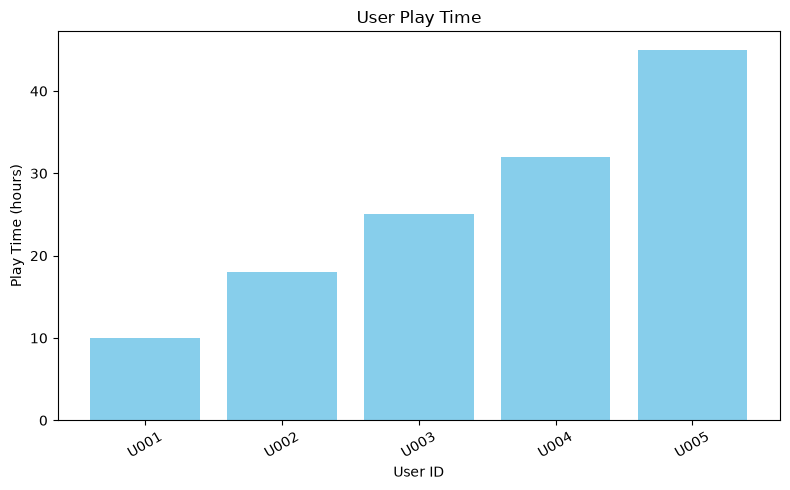

In [13]:
# Visualization example using only English labels
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DejaVu Sans"

plt.figure(figsize=(8, 5))
plt.bar(players["user_id"], players["play_time_hours"], color="skyblue")
plt.title("User Play Time")
plt.xlabel("User ID")
plt.ylabel("Play Time (hours)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 8. EDA 해석: 그래프에서 의미 찾기

EDA의 목적은 데이터가 말하는 이야기를 찾는 것입니다. 단순히 숫자를 보기보다, 이 숫자가 어떤 의미를 가지는지 해석해야 합니다.

예를 들어 데이터가 아래처럼 보인다면:

- 레벨이 높을수록 플레이 시간이 늘어난다.
- 고소비 유저는 승률이 더 높다.
- 협동 모드 유저는 경쟁 모드보다 더 오래 플레이한다.

이렇게 패턴이 보이면, 나중에 실제 게임 기획이나 서비스 개선 아이디어로 연결할 수 있습니다.

주요 질문은 다음과 같습니다.

- 데이터가 우리 질문에 답을 주는가?
- 어떤 패턴이 반복되는가?
- 왜 그런 패턴이 생겼을 가능성이 있는가?
- 분석 결과를 어떻게 설명할 수 있는가?

In [10]:
# EDA 결과를 간단하게 해석하는 예시
print("분석 가설 1: 플레이 시간이 길수록 승률이 높을 가능성이 있다.")
print("분석 가설 2: 게임 머니를 많이 지출한 유저는 높은 레벨을 달성할 가능성이 있다.")
print("분석 가설 3: 특정 모드에서 유저의 유지율이 높을 수 있다.")

분석 가설 1: 플레이 시간이 길수록 승률이 높을 가능성이 있다.
분석 가설 2: 게임 머니를 많이 지출한 유저는 높은 레벨을 달성할 가능성이 있다.
분석 가설 3: 특정 모드에서 유저의 유지율이 높을 수 있다.


## 9. 해석과 보고: 결과를 설명하기

분석이 끝났다고 해서 끝이 아닙니다. 결과를 이해하기 쉽게 정리하고 보고서 형태로 제시하는 단계가 필요합니다.

보고서에는 다음 내용을 포함하는 것이 좋습니다.

- 문제 정의
- 사용한 데이터와 수집 방법
- 전처리 과정
- 분석 결과
- 시각화 결과
- 결론과 시사점

예시 보고문은 다음처럼 작성할 수 있습니다.

> 게임 이용자 데이터를 분석한 결과, 높은 레벨 유저가 더 긴 플레이 시간을 보였고, 지출이 많은 유저일수록 승률이 높게 나타났습니다. 특히 경쟁 모드를 선호하는 유저의 평균 승률이 높았으며, 이러한 결과는 게임의 경쟁 요소가 유저 유지에 긍정적인 영향을 미친다는 가능성을 보여줍니다.

In [11]:
# 간단한 보고 결론 생성
report = {
    "문제": "게임에서 어떤 요소가 유저 참여를 높이는가?",
    "핵심결론": "플레이 시간이 길고, 지출이 높은 유저는 높은 승률과 레벨을 보이는 경향이 있다.",
    "추천": "게임 내 경쟁 요소와 보상 체계를 강화해 유저 유지율을 높일 수 있다.",
}

for key, value in report.items():
    print(f"{key}: {value}")

문제: 게임에서 어떤 요소가 유저 참여를 높이는가?
핵심결론: 플레이 시간이 길고, 지출이 높은 유저는 높은 승률과 레벨을 보이는 경향이 있다.
추천: 게임 내 경쟁 요소와 보상 체계를 강화해 유저 유지율을 높일 수 있다.


## 10. 전체 분석 흐름 정리

게임 데이터를 분석할 때 가장 중요한 것은 다음의 흐름을 기억하는 것입니다.

1. 질문 정의: 무엇을 알고 싶은지 정한다.
2. 데이터 수집: 필요한 데이터를 모은다.
3. 전처리: 비어 있거나 잘못된 값을 정리한다.
4. EDA: 그래프와 통계를 통해 패턴을 찾는다.
5. 해석과 보고: 결과를 의미 있게 설명한다.

이 흐름은 게임 데이터만이 아니라 학교 프로젝트, 과학 실험, 사회 문제 분석 등 다른 분야에도 적용할 수 있습니다.

In [12]:
# 전체 프로세스 확인
process = [
    "질문 정의",
    "데이터 수집",
    "전처리",
    "탐색적 분석(EDA)",
    "해석과 보고",
]
print("데이터 분석 프로젝트의 기본 단계:")
for i, step in enumerate(process, start=1):
    print(f"{i}. {step}")

# 간단한 검증
assert len(process) == 5
assert process[0] == "질문 정의"
print("Chapter 16 실습 검증 통과")

데이터 분석 프로젝트의 기본 단계:
1. 질문 정의
2. 데이터 수집
3. 전처리
4. 탐색적 분석(EDA)
5. 해석과 보고
Chapter 16 실습 검증 통과


## 실습 과제

1. 게임 유저 데이터 CSV를 직접 만들어 보세요.
2. `pandas`로 데이터프레임을 만들고 결측값을 처리해 보세요.
3. `level`과 `play_time_hours`의 관계를 확인해 보세요.
4. 그룹별 평균을 계산해서 어떤 게임 모드가 인기 있는지 분석해 보세요.
5. 결과를 3~5문장으로 정리해 보세요.